# Wstęp

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('zdalna8.csv')

In [3]:
df = df.rename(columns={'study mode': 'full-online'})

In [4]:
df.columns

Index(['full-online', 'PU1', 'PU2', 'PU3', 'PU4', 'PU5', 'PU6', 'PEOU1',
       'PEOU2', 'PEOU3', 'PEOU4', 'PEOU5', 'PEOU6', 'PEOU7', 'PEOU8', 'PEOU9',
       'BI1', 'BI2', 'BI3', 'ENG1', 'ENG2', 'NEG1', 'NEG2', 'NEG3', 'NEG4',
       'NEG5', 'NEG6', 'NEG7', 'POS1', 'POS2', 'POS3', 'POS4', 'employment',
       'full-time-study', 'study level', 'study program', 'age', 'gender',
       'abroad', 'remote_area', 'has_children', 'caregiver',
       'health_limitation', 'is_Polish', 'goal_diploma', 'goal_skills',
       'goal_move_out', 'goal_social_life', 'goal_partner',
       'study level_bachelor', 'study level_long-master', 'study level_master',
       'study program_Computer Science', 'study program_Cosmetology',
       'study program_Cybersecurity', 'study program_Dietetics',
       'study program_English Philology', 'study program_Fashion Design',
       'study program_Finance and Accounting',
       'study program_German Philology', 'study program_Law',
       'study program_Managem

In [5]:
X_col = ['full-online', 'employment',
       'full-time-study', 'age', 'gender',
       'abroad', 'remote_area', 'has_children', 'caregiver',
       'health_limitation', 'is_Polish', 
       'study level_bachelor', 'study level_long-master', 'study level_master',
       'PU', 'PEOU',
       'ENG', 'NEG', 'POS',
       'goal_social', 'goal_instrumental',
       'study_program_it', 'study_program_business',
       'study_program_social_sciences', 'study_program_humanities',
       'study_program_applied']
Y_col = 'BI'

# Korelacje

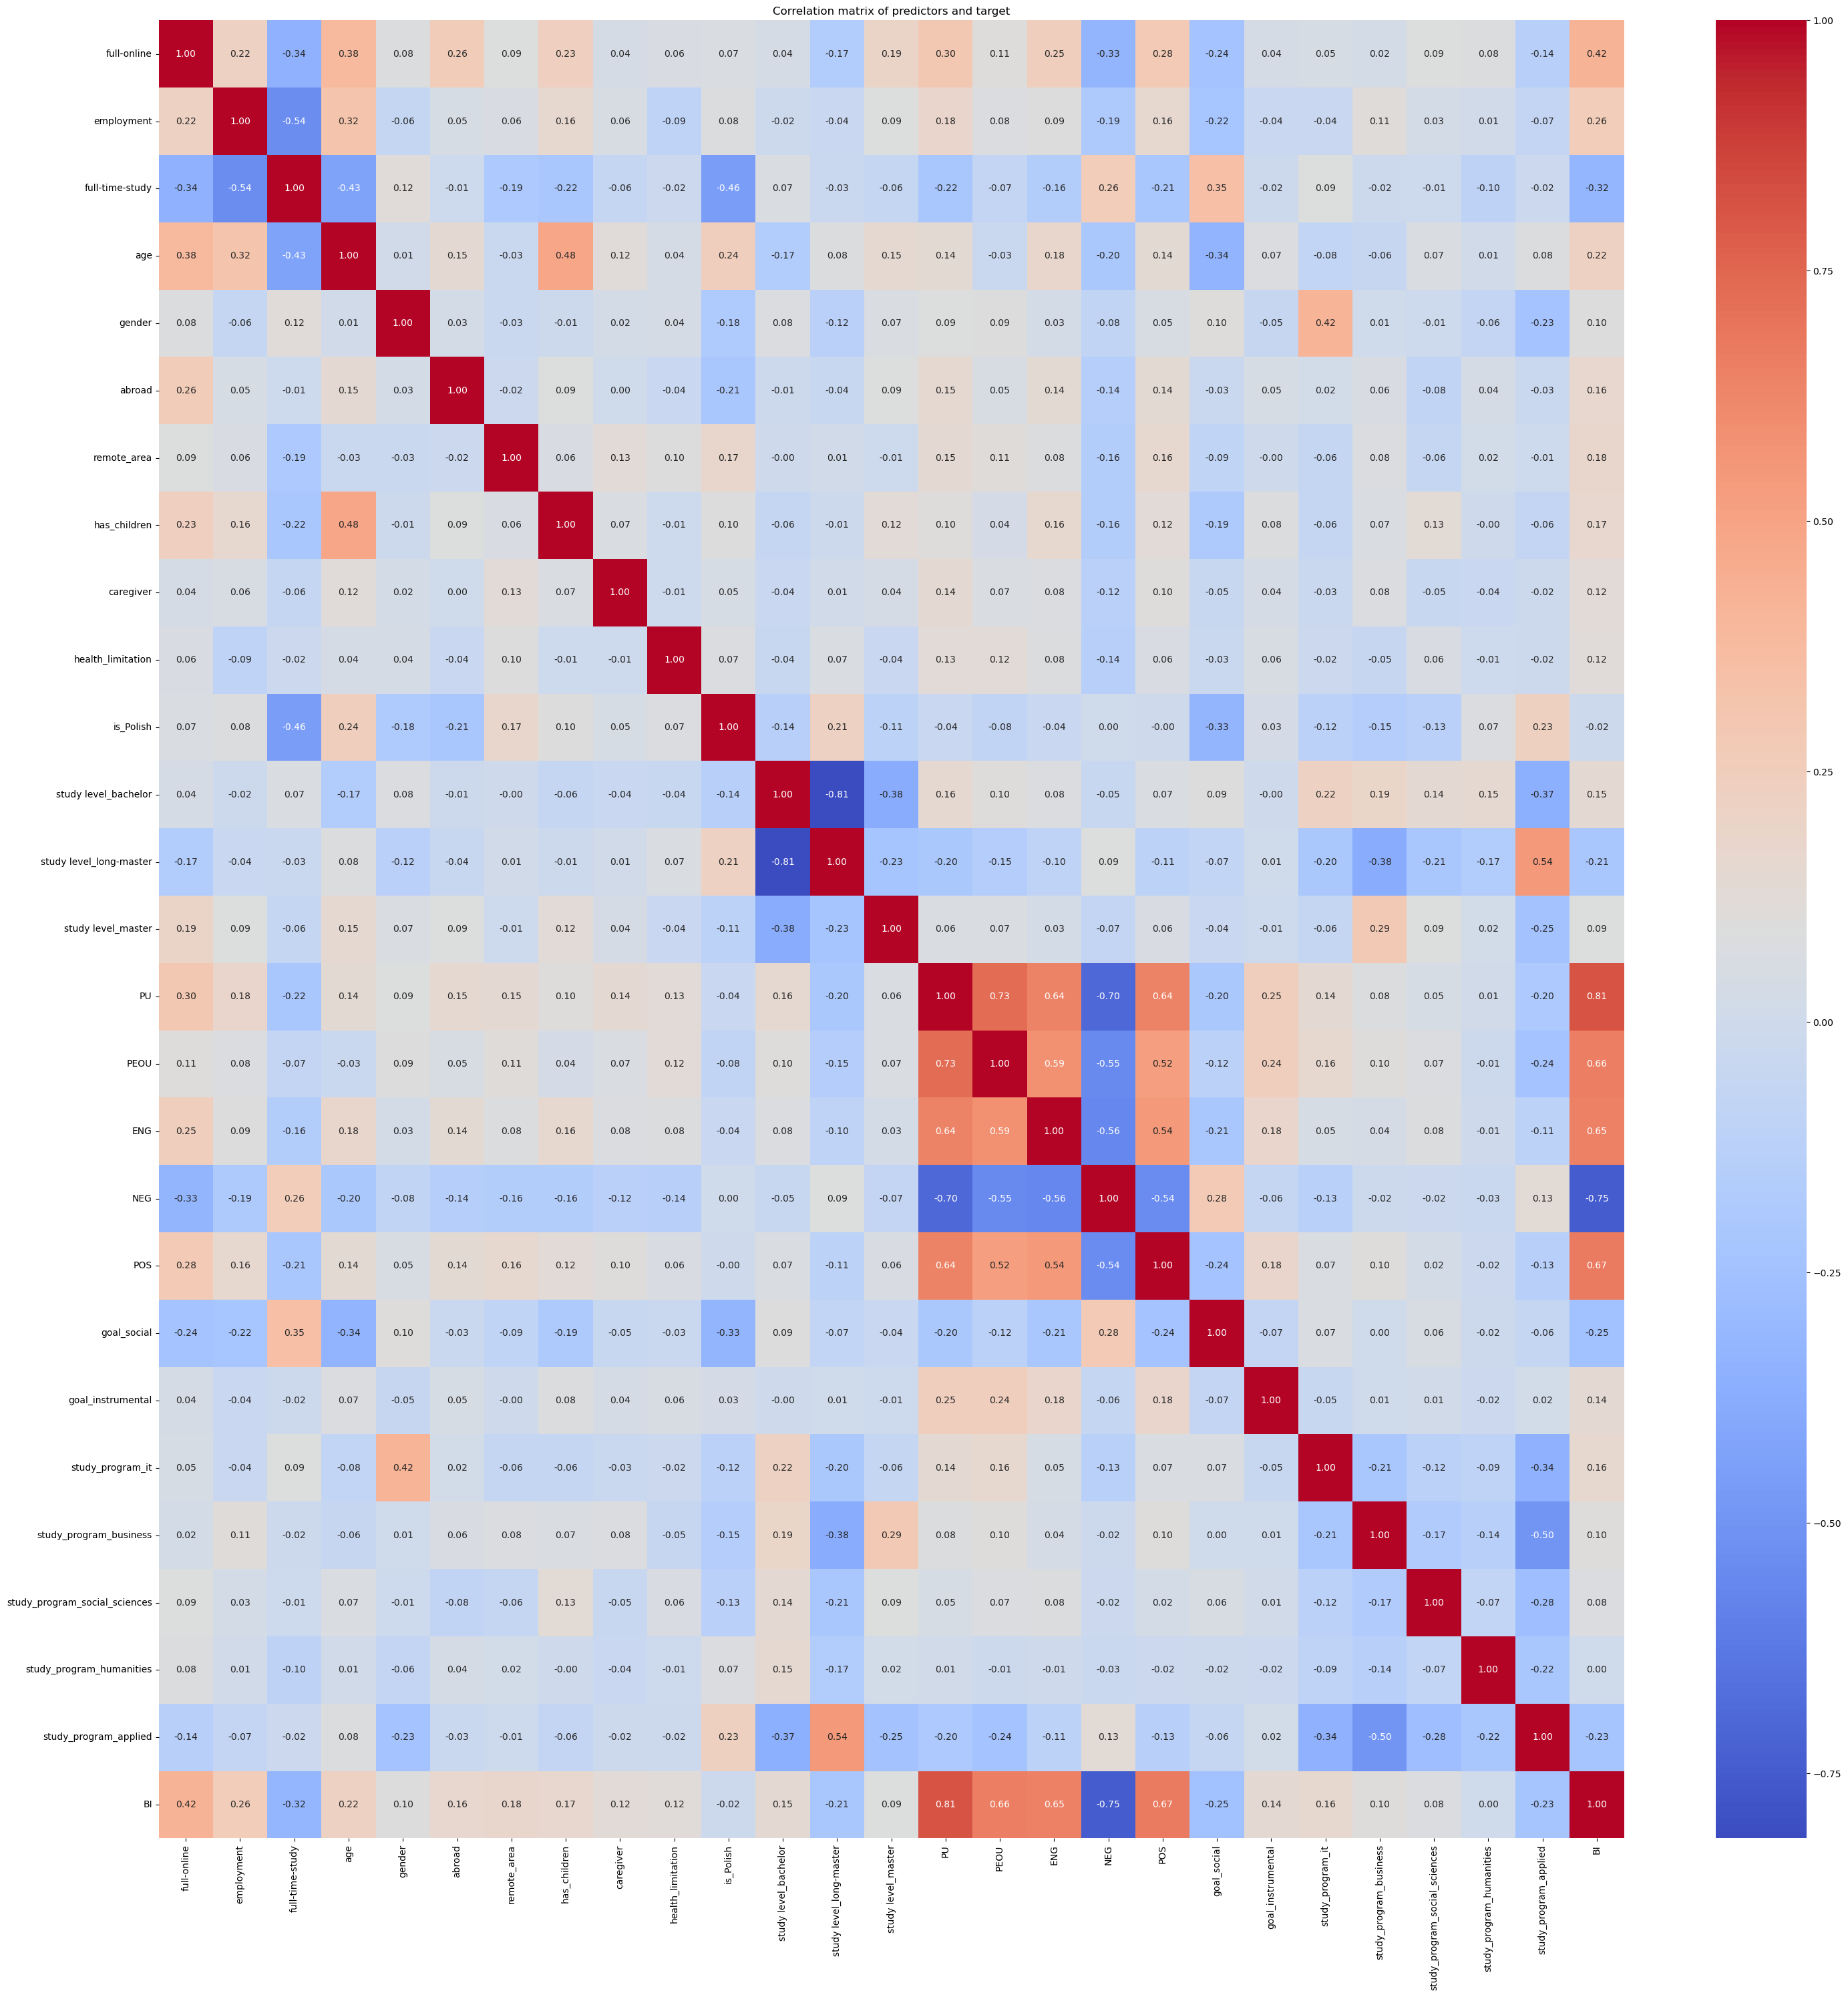

In [7]:
cols_to_corr = X_col + [Y_col]  # uwzględniamy też target BI
corr_matrix = df[cols_to_corr].corr()

# Rysowanie heatmapy
plt.figure(figsize=(30, 30))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation matrix of predictors and target")
plt.tight_layout()

# Zapis do pliku PNG
plt.savefig("correlation_matrix.png", dpi=300)
plt.show()

In [8]:
df_corr = df[cols_to_corr]
correlations = df_corr.corr(numeric_only=True)['BI'].drop('BI')
print(correlations)

full-online                      0.422855
employment                       0.256250
full-time-study                 -0.320113
age                              0.223014
gender                           0.098040
abroad                           0.164474
remote_area                      0.175187
has_children                     0.170518
caregiver                        0.123990
health_limitation                0.119140
is_Polish                       -0.020640
study level_bachelor             0.145318
study level_long-master         -0.208889
study level_master               0.089174
PU                               0.810411
PEOU                             0.655576
ENG                              0.650456
NEG                             -0.746819
POS                              0.667204
goal_social                     -0.248073
goal_instrumental                0.144457
study_program_it                 0.158153
study_program_business           0.100458
study_program_social_sciences    0

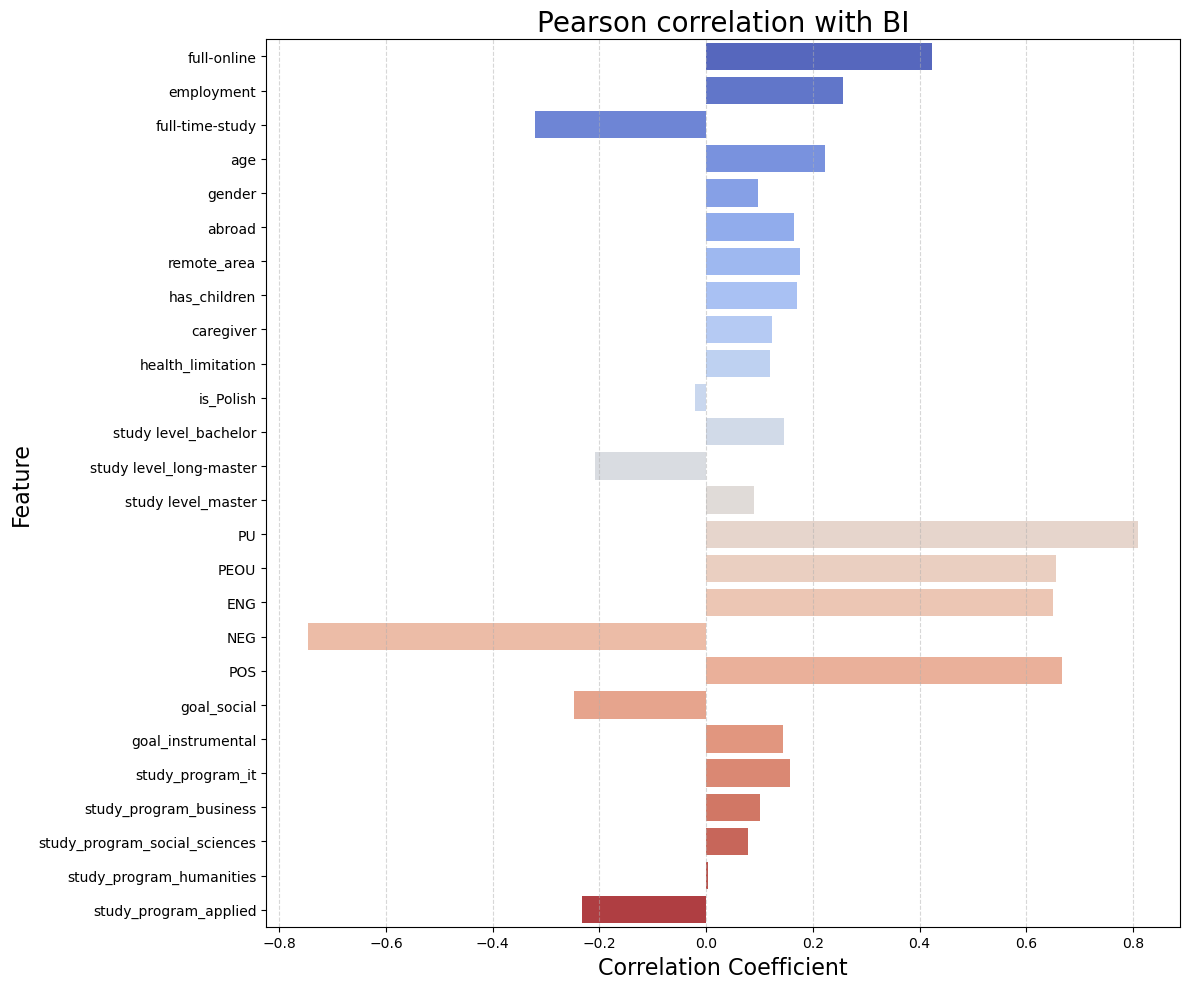

In [9]:
cor_df = correlations.reset_index()
cor_df.columns = ['variable', 'correlation']

# Big plot
plt.figure(figsize=(12, 10))  # <-- Zmieniony rozmiar
sns.barplot(
    data=cor_df,
    x='correlation',
    y='variable',
    hue='variable',
    palette='coolwarm',
    dodge=False,
    legend=False,
    errorbar=None
)
plt.title('Pearson correlation with BI', fontsize=20)
plt.xlabel('Correlation Coefficient', fontsize=16)
plt.ylabel('Feature', fontsize=16)

plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("Ver2Correlation with BI.jpeg", format='jpeg', dpi=300)
plt.show()

# ElasticNet

## Elastic Net ze stratified

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

X = df[X_col]
Y = df[Y_col]
# Zakładam, że masz X i Y
Y_binned = pd.qcut(Y, q=10, duplicates='drop')
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y_binned)

# Pipeline: scaling + ElasticNet
pipeline = make_pipeline(
    StandardScaler(),
    ElasticNet(max_iter=5000)  # zwiększamy iteracje dla pewności zbieżności
)

# Parametry do losowego przeszukiwania
param_dist = {
    'elasticnet__alpha': np.logspace(-3, 1, 50),      # od 0.001 do 10
    'elasticnet__l1_ratio': np.linspace(0, 1, 50)     # od Ridge do Lasso
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=30,          # liczba losowych kombinacji
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Dopasowanie modelu
random_search.fit(X_train, Y_train)

# Najlepsze parametry
best_params = random_search.best_params_
best_score_cv = random_search.best_score_
print(f"Best parameters: {best_params}")
print(f"Best cross-validation R^2: {best_score_cv:.3f}")

# Ocena na zbiorze testowym
best_model = random_search.best_estimator_
Y_pred_train = best_model.predict(X_train)
Y_pred_test = best_model.predict(X_test)

r2_train = r2_score(Y_train, Y_pred_train)
r2_test = r2_score(Y_test, Y_pred_test)

rmse_train = np.sqrt(mean_squared_error(Y_train, Y_pred_train))
rmse_test = np.sqrt(mean_squared_error(Y_test, Y_pred_test))

print(f"Train set: R^2 = {r2_train:.3f}, RMSE = {rmse_train:.3f}")
print(f"Test set:  R^2 = {r2_test:.3f}, RMSE = {rmse_test:.3f}")

# Współczynniki modelu
elastic_model = best_model.named_steps['elasticnet']
coefs = pd.Series(elastic_model.coef_, index=X_train.columns)
coefs_ranked = coefs.sort_values(key=abs, ascending=False)

print("Feature ranking (by absolute coefficient):")
print(coefs_ranked)

Best parameters: {'elasticnet__l1_ratio': np.float64(0.2857142857142857), 'elasticnet__alpha': np.float64(0.10985411419875583)}
Best cross-validation R^2: 0.764
Train set: R^2 = 0.780, RMSE = 0.640
Test set:  R^2 = 0.800, RMSE = 0.618
Feature ranking (by absolute coefficient):
PU                               0.401218
NEG                             -0.324643
PEOU                             0.171267
POS                              0.163963
ENG                              0.150687
full-online                      0.142157
full-time-study                 -0.078646
employment                       0.050616
study_program_applied           -0.047942
study level_long-master         -0.027654
study_program_it                 0.018153
remote_area                      0.004045
age                              0.002753
health_limitation                0.000000
gender                           0.000000
caregiver                        0.000000
has_children                     0.000000
abroad  

# Drzewo Decyzyjne

## DT ze stratyfikacją

In [14]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# X i Y
X = df[X_col]
Y = df[Y_col]

# Podział na train/test
Y_binned = pd.qcut(Y, q=10, duplicates='drop')
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y_binned)

# Model drzewa regresyjnego
tree = DecisionTreeRegressor(random_state=42)

# Parametry do losowego przeszukiwania
param_dist = {
    'max_depth': [None] + list(range(2, 20)),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    tree,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Dopasowanie modelu
random_search.fit(X_train, Y_train)

# Najlepszy model
best_tree = random_search.best_estimator_

# Ocena modelu
y_pred_train = best_tree.predict(X_train)
y_pred_test = best_tree.predict(X_test)

r2_train = r2_score(Y_train, y_pred_train)
r2_test = r2_score(Y_test, y_pred_test)

rmse_train = np.sqrt(mean_squared_error(Y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(Y_test, y_pred_test))

print(f"Train set: R^2 = {r2_train:.3f}, RMSE = {rmse_train:.3f}")
print(f"Test set:  R^2 = {r2_test:.3f}, RMSE = {rmse_test:.3f}")
print(f"Best parameters: {random_search.best_params_}")



Train set: R^2 = 0.852, RMSE = 0.525
Test set:  R^2 = 0.746, RMSE = 0.696
Best parameters: {'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': None, 'max_depth': 16}


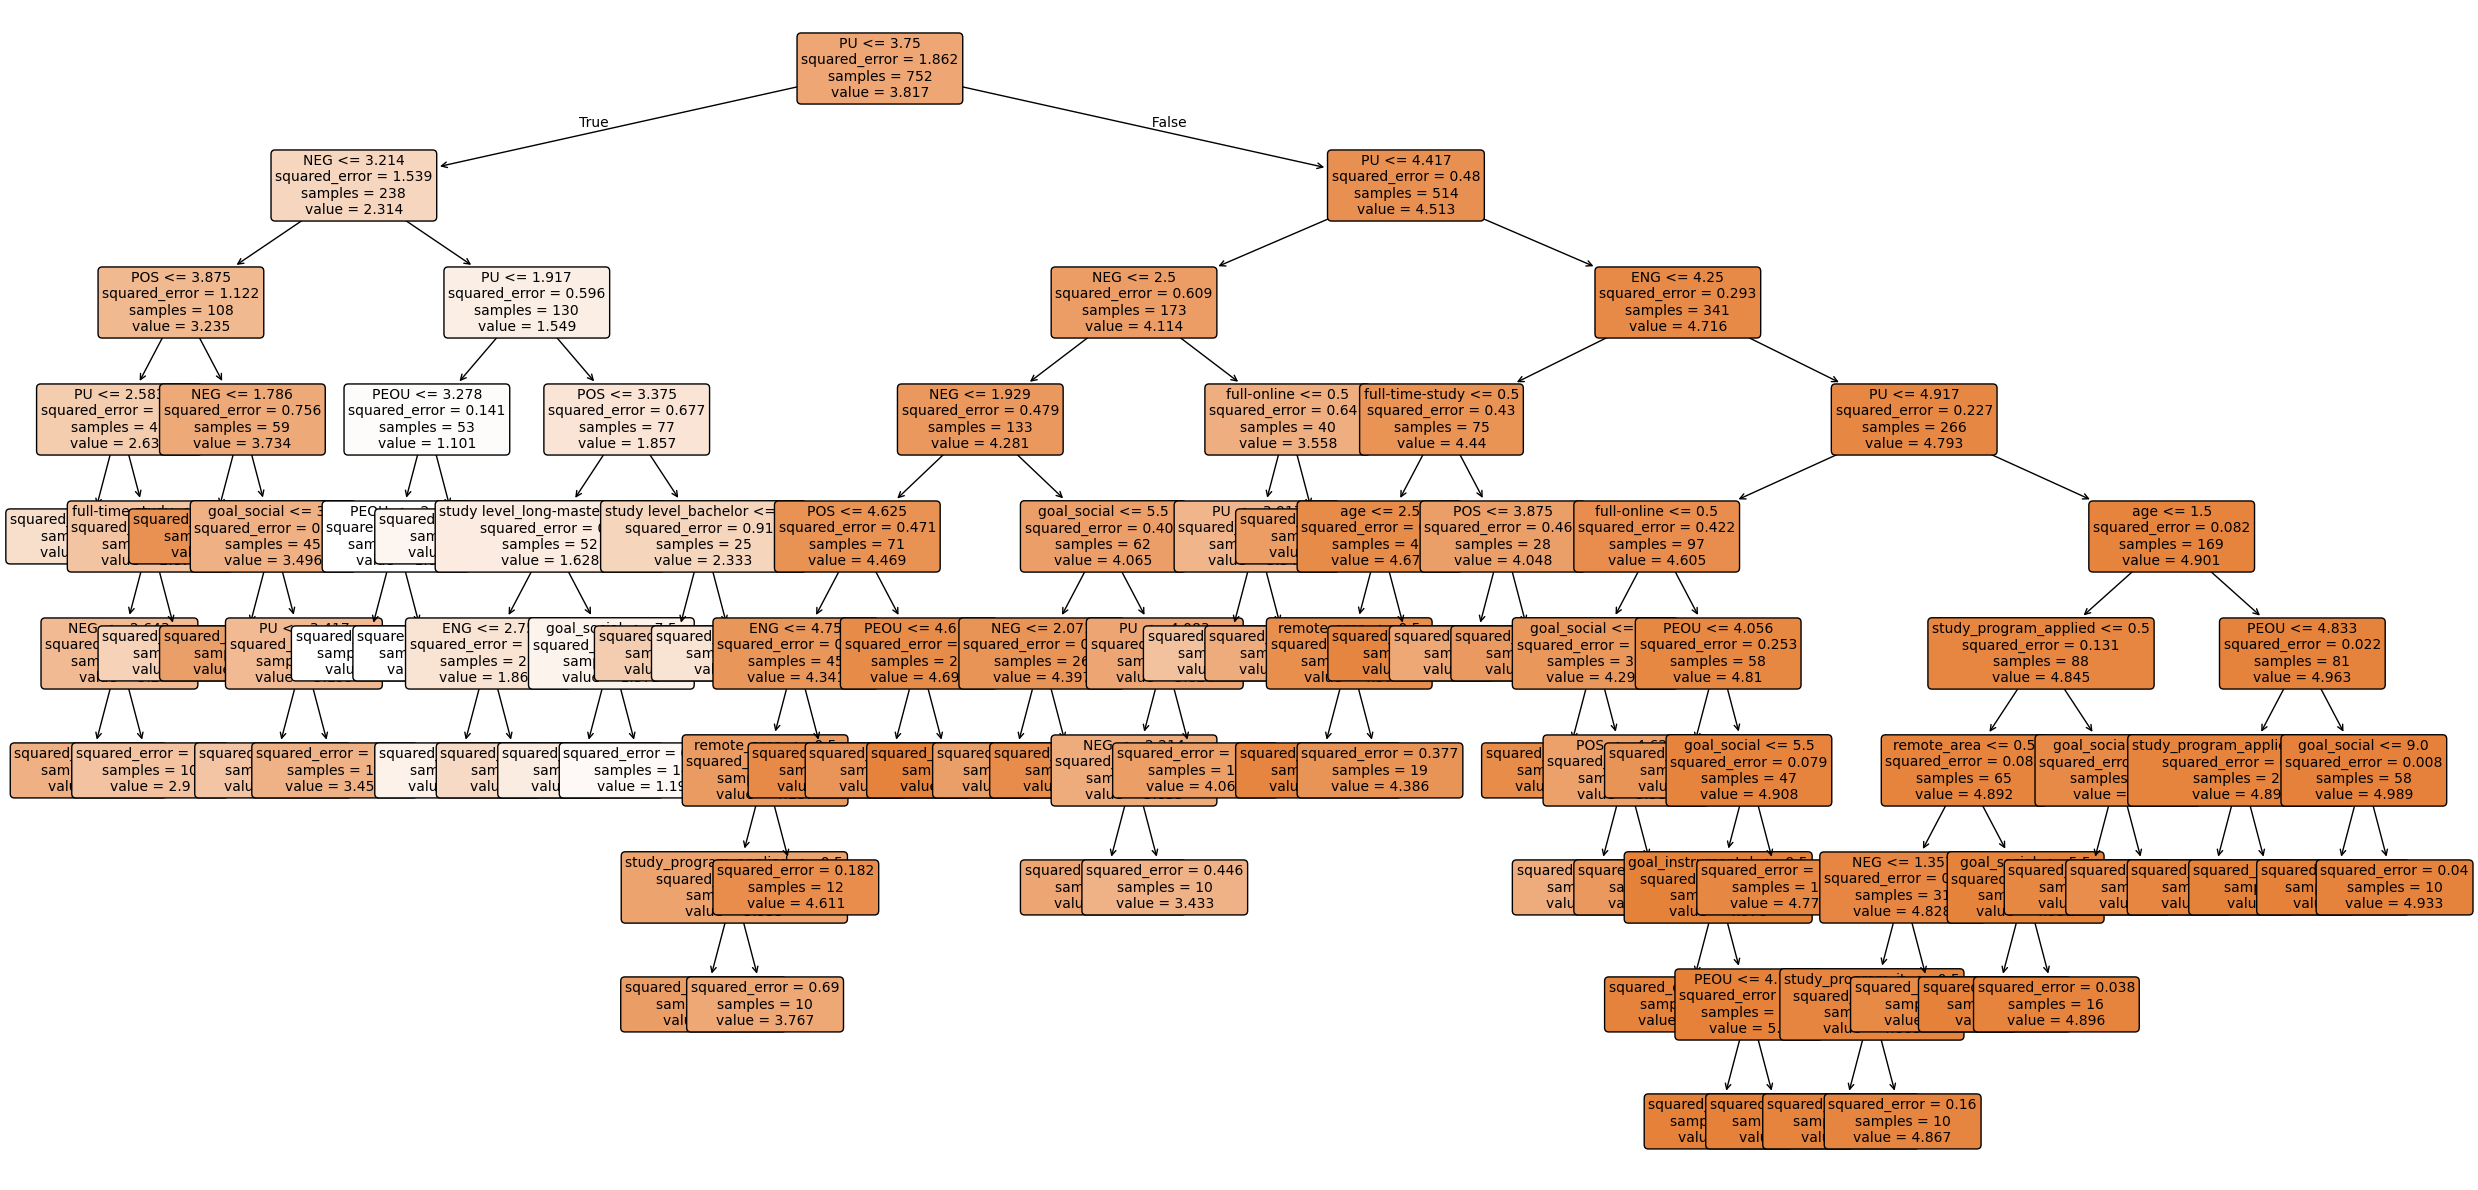

In [17]:
# Wykres drzewa do PNG
plt.figure(figsize=(25,12))  # duży rozmiar dla czytelności
plot_tree(
    best_tree, 
    rounded=True,
    feature_names=X_train.columns, 
    filled=True, 
    fontsize=10)
plt.tight_layout()
plt.savefig("Ver2decision_tree.png", dpi=300)  # zapis do pliku PNG w wysokiej rozdzielczości
plt.show()
plt.close()

In [19]:
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
tree_rules = export_text(
    best_tree,
    feature_names=list(X_train.columns)
)

print("\nText representation of the decision tree:\n")
print(tree_rules)


Text representation of the decision tree:

|--- PU <= 3.75
|   |--- NEG <= 3.21
|   |   |--- POS <= 3.88
|   |   |   |--- PU <= 2.58
|   |   |   |   |--- value: [2.02]
|   |   |   |--- PU >  2.58
|   |   |   |   |--- full-time-study <= 0.50
|   |   |   |   |   |--- NEG <= 2.64
|   |   |   |   |   |   |--- value: [3.50]
|   |   |   |   |   |--- NEG >  2.64
|   |   |   |   |   |   |--- value: [2.90]
|   |   |   |   |--- full-time-study >  0.50
|   |   |   |   |   |--- value: [2.44]
|   |   |--- POS >  3.88
|   |   |   |--- NEG <= 1.79
|   |   |   |   |--- value: [4.50]
|   |   |   |--- NEG >  1.79
|   |   |   |   |--- goal_social <= 3.50
|   |   |   |   |   |--- value: [4.04]
|   |   |   |   |--- goal_social >  3.50
|   |   |   |   |   |--- PU <= 3.42
|   |   |   |   |   |   |--- value: [2.83]
|   |   |   |   |   |--- PU >  3.42
|   |   |   |   |   |   |--- value: [3.45]
|   |--- NEG >  3.21
|   |   |--- PU <= 1.92
|   |   |   |--- PEOU <= 3.28
|   |   |   |   |--- PEOU <= 2.00
|   |   

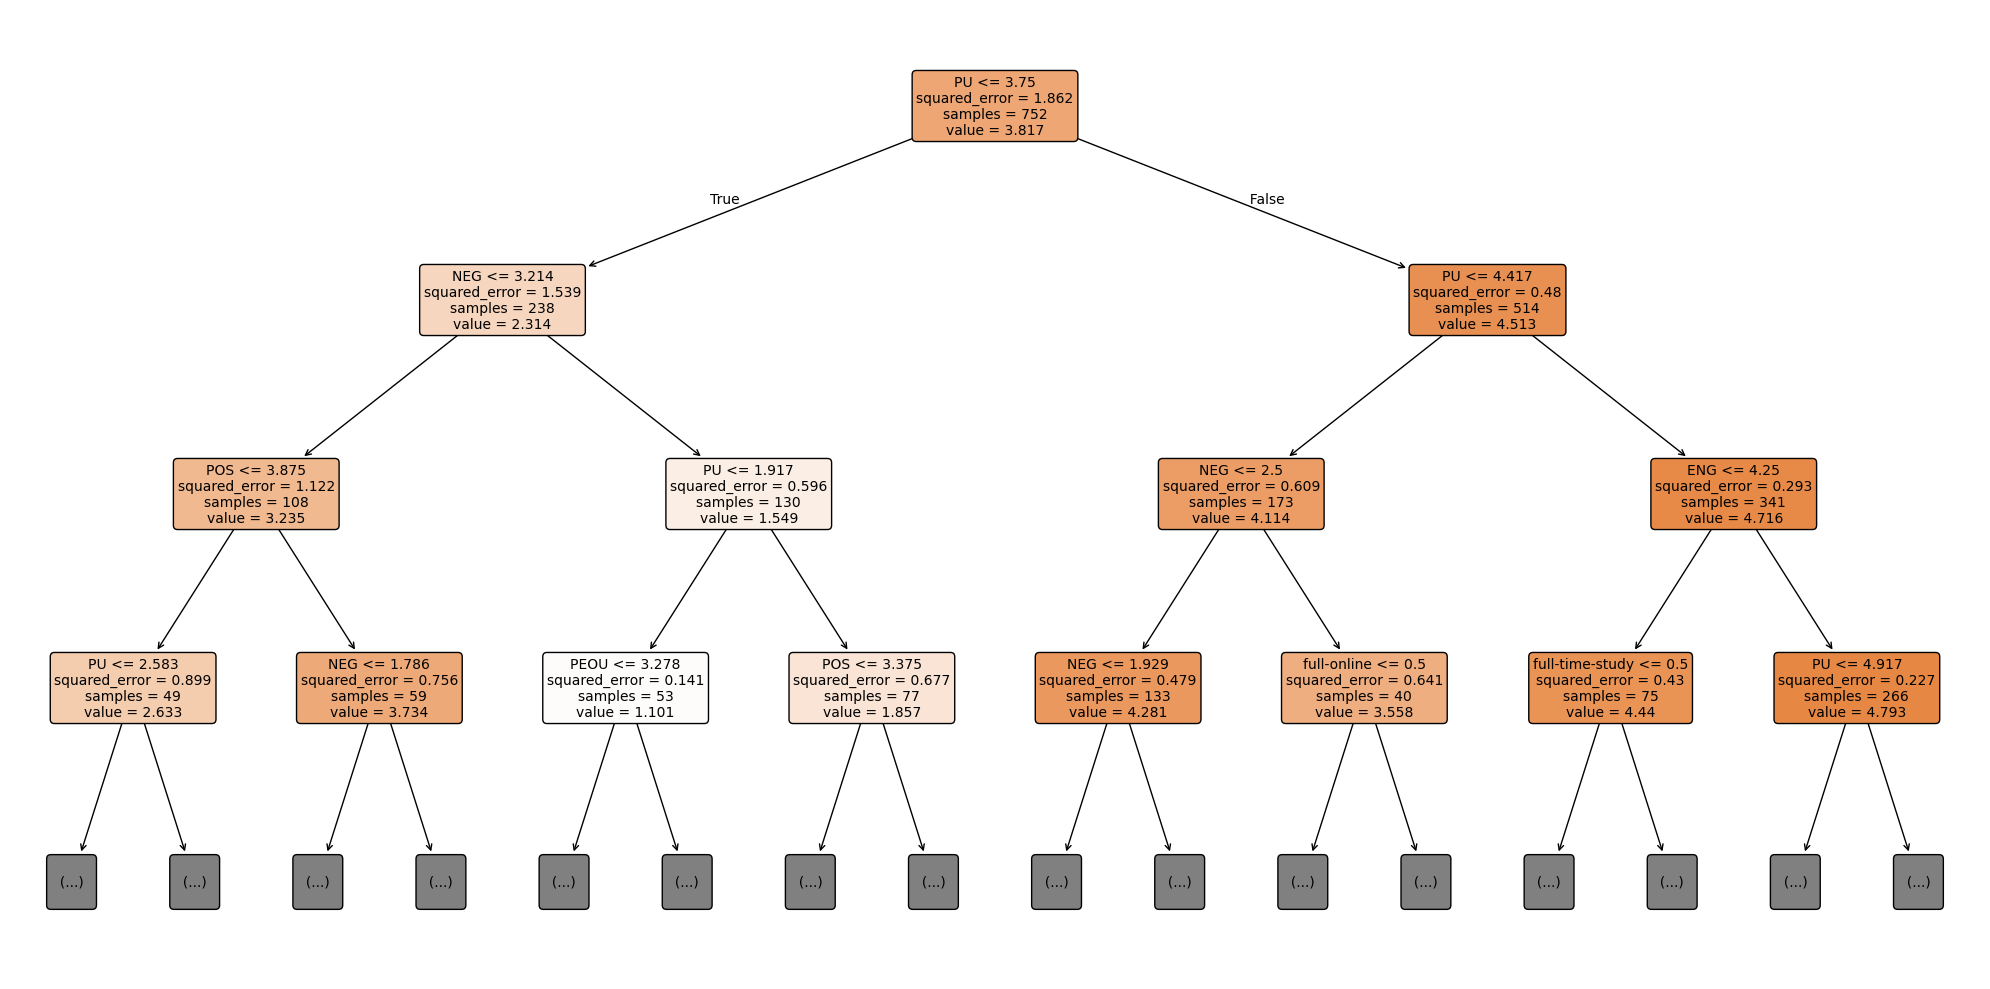

In [20]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    best_tree,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3   # tylko wizualizacja do głębokości 4
)

plt.tight_layout()

plt.savefig("Ver2decision_tree_depth4_visualizationStrat.png", dpi=300)
plt.show()
plt.close()

# Random Forest

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# X i Y
X = df[X_col]
Y = df[Y_col]

# Stratified train/test split (binujemy target na 10 przedziałów)
Y_binned = pd.qcut(Y, q=10, duplicates='drop')
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y_binned
)

# Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Parametry do losowego przeszukiwania
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None] + list(range(2, 15)),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,            # losujemy 30 kombinacji
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Dopasowanie modelu
random_search_rf.fit(X_train, Y_train)

# Najlepszy model
best_rf = random_search_rf.best_estimator_

# Ocena modelu
y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

r2_train = r2_score(Y_train, y_pred_train)
r2_test = r2_score(Y_test, y_pred_test)

rmse_train = np.sqrt(mean_squared_error(Y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(Y_test, y_pred_test))

print(f"Train set: R^2 = {r2_train:.3f}, RMSE = {rmse_train:.3f}")
print(f"Test set:  R^2 = {r2_test:.3f}, RMSE = {rmse_test:.3f}")
print(f"Best parameters: {random_search_rf.best_params_}")

Train set: R^2 = 0.984, RMSE = 0.172
Test set:  R^2 = 0.821, RMSE = 0.584
Best parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 14, 'bootstrap': False}


In [22]:
import pandas as pd
import numpy as np

# Tworzymy DataFrame z nazwami cech i feature importance
fi = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
})

# Sortujemy po wartości bezwzględnej malejąco
fi_sorted = fi.reindex(fi['importance'].abs().sort_values(ascending=False).index)

# Wyświetlamy
print(fi_sorted)

                          feature  importance
14                             PU    0.263234
17                            NEG    0.215126
18                            POS    0.148015
15                           PEOU    0.122768
16                            ENG    0.083402
0                     full-online    0.034976
19                    goal_social    0.023260
2                 full-time-study    0.015758
3                             age    0.015549
1                      employment    0.011115
20              goal_instrumental    0.009658
25          study_program_applied    0.009086
12        study level_long-master    0.006845
11           study level_bachelor    0.005374
6                     remote_area    0.005166
4                          gender    0.003899
21               study_program_it    0.003729
10                      is_Polish    0.003548
22         study_program_business    0.003300
7                    has_children    0.003291
23  study_program_social_sciences 

SHAP values computed for test set.


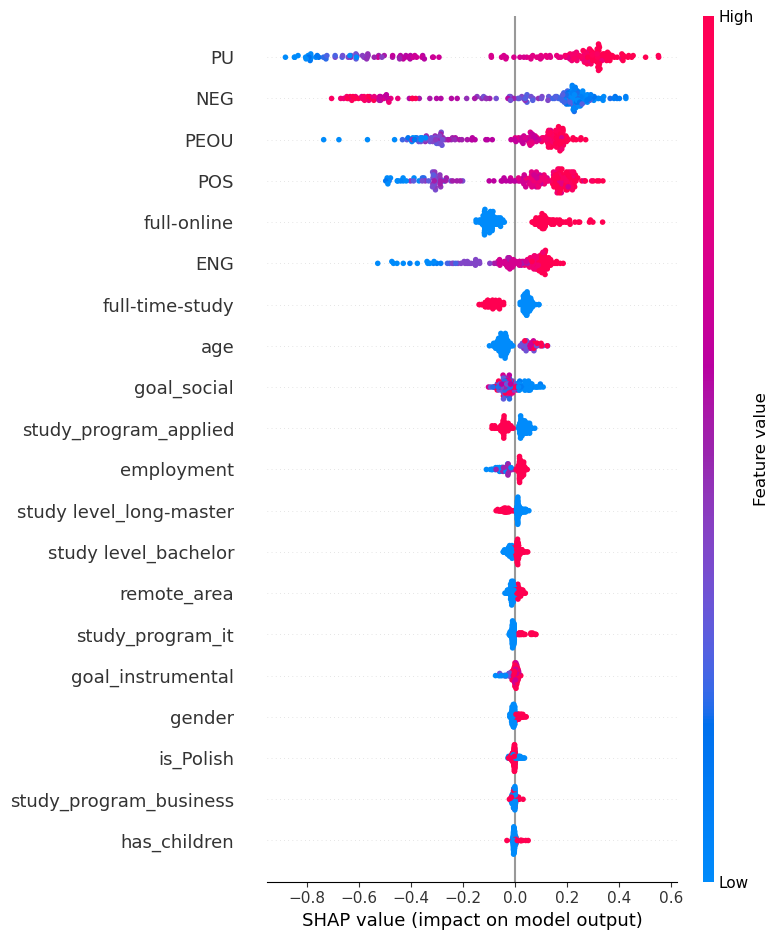

In [23]:
import shap

# Zakładamy, że best_rf to Twój wytrenowany RandomForestRegressor
# X_train i X_test są jak wcześniej

# Tworzymy obiekt Explainer dla lasu losowego
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed for test set.")
# Wykres sumaryczny SHAP
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
# Zapis do pliku PNG
plt.tight_layout()
plt.savefig("Ver2shap_summary_plot.png", dpi=300)
plt.show()
plt.close()


# GAM


100% (11 of 11) |########################| Elapsed Time: 0:00:05 Time:  0:00:050:00
C:\Users\User\AppData\Local\Temp\ipykernel_21288\2127755070.py:49: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())  # statystyki: lambdy, edf, testy, p-value


Train set: R^2 = 0.801, RMSE = 0.608
Test set:  R^2 = 0.811, RMSE = 0.601
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     38.6232
Link Function:                     IdentityLink Log Likelihood:                                  -693.8181
Number of Samples:                          752 AIC:                                             1466.8825
                                                AICc:                                            1471.4079
                                                GCV:                                                0.4297
                                                Scale:                                              0.6246
                                                Pseudo R-Squared:     

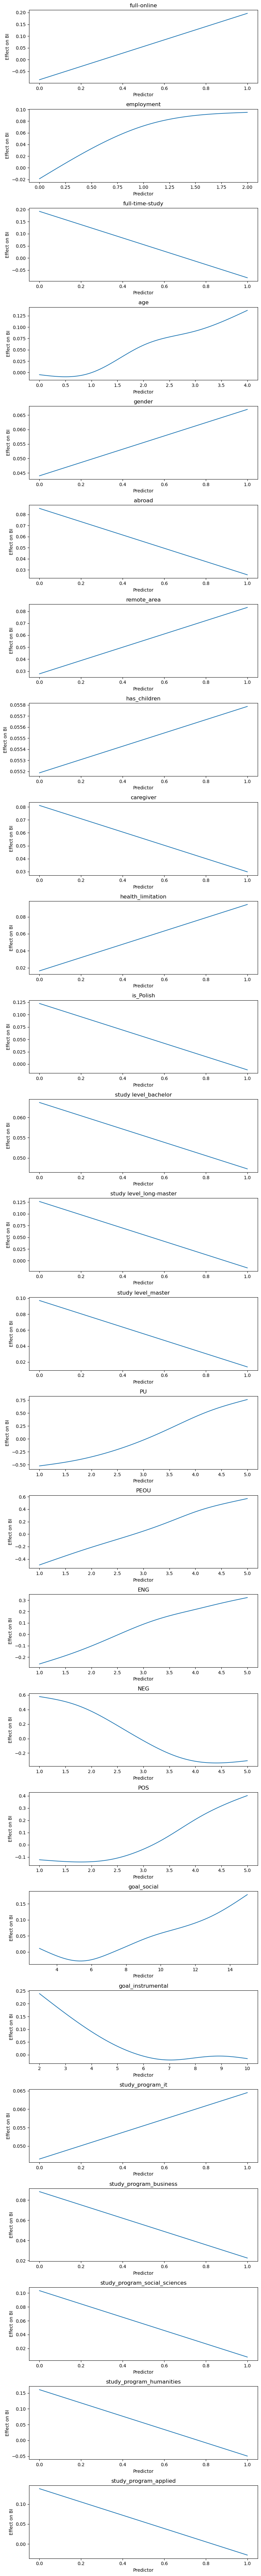

In [25]:
# ------------------------------------------
# GAM w stylu Twojego ElasticNet / Decision Tree
# ------------------------------------------
from pygam import LinearGAM
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

# X i Y
X = df[X_col].values      # tablica NumPy dla pygam
Y = df[Y_col].values

# Stratyfikowany podział train/test
Y_binned = pd.qcut(Y, q=10, duplicates='drop')  # tworzymy 10 binów
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y_binned
)

# ------------------------------------------
# Definicja GAM
# ------------------------------------------
gam = LinearGAM()  # automatyczne spline dla każdej zmiennej

# Gridsearch: strojenie parametrów wygładzania (lambda)
gam.gridsearch(X_train, Y_train)  # domyślnie 5-fold CV w train

# ------------------------------------------
# Predykcje
# ------------------------------------------
Y_pred_train = gam.predict(X_train)
Y_pred_test = gam.predict(X_test)

# ------------------------------------------
# Metryki
# ------------------------------------------
r2_train = r2_score(Y_train, Y_pred_train)
r2_test = r2_score(Y_test, Y_pred_test)

rmse_train = np.sqrt(mean_squared_error(Y_train, Y_pred_train))
rmse_test = np.sqrt(mean_squared_error(Y_test, Y_pred_test))

print(f"Train set: R^2 = {r2_train:.3f}, RMSE = {rmse_train:.3f}")
print(f"Test set:  R^2 = {r2_test:.3f}, RMSE = {rmse_test:.3f}")

# ------------------------------------------
# Podsumowanie modelu
# ------------------------------------------
print(gam.summary())  # statystyki: lambdy, edf, testy, p-value

# ------------------------------------------
# Wykresy zależności częściowych (partial dependence)
# ------------------------------------------
import matplotlib.pyplot as plt

fig, axs = plt.subplots(len(X_col), 1, figsize=(8, 3*len(X_col)))

for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.set_title(X_col[i])
    ax.set_xlabel("Predictor")
    ax.set_ylabel("Effect on BI")

plt.tight_layout()
plt.show()